# Laboratorium 9:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
%matplotlib inline


In [2]:
df = pd.read_excel('data.xlsx', engine='openpyxl')

print(f'Wczytano {len(df)} wierszy i {len(df.columns)} kolumn')
df.drop(df.columns[0], axis=1, inplace=True)
display(df.head())

X = df['X'].values.reshape(-1, 1)
y = df['Y'].values

print(f"X shape: {X.shape}, y shape: {y.shape}")

Wczytano 100 wierszy i 3 kolumn


,X,Y
0,-0.015981,0.001984
1,-0.012942,-0.000511
2,-0.018796,0.008553
3,-0.019340,-0.019842
4,0.015664,-0.002325


X shape: (100, 1), y shape: (100,)


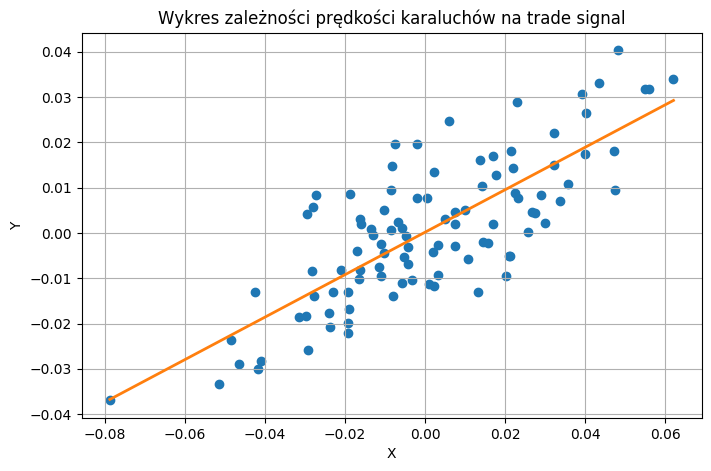

In [3]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
mse = mean_squared_error(y, y_pred)
sort_idx = X.ravel().argsort()
y_pred_sorted = y_pred[sort_idx]

plt.figure(figsize=(8,5))
plt.scatter(X.ravel(), y, c='C0')
plt.plot(X.ravel()[sort_idx], y_pred_sorted, c='C1', linewidth=2, )
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Wykres zależności prędkości karaluchów na trade signal')
plt.grid(True)
plt.show()


### Funkcja straty pasująca do naszego problemu:

In [4]:
def stock_loss(factual, predicted, coef = 100.):
    if factual * predicted < 0:
        return coef * predicted**2 + abs(factual - predicted)
    else:
        return abs(factual - predicted)

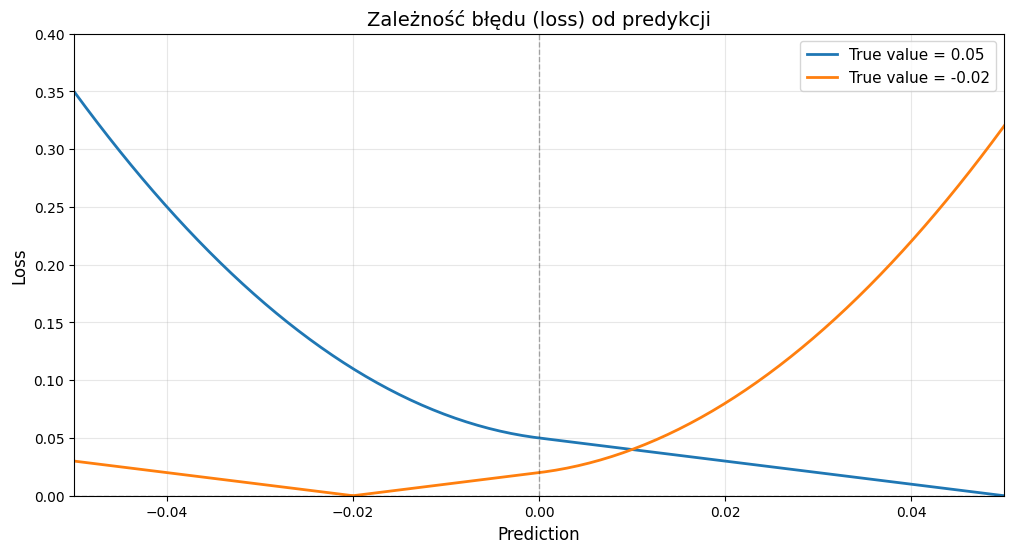

In [21]:
predictions = np.linspace(-0.1, 0.1, 500)

true_values = [0.05, -0.02]
colors = ['C0', 'C1']

plt.figure(figsize=(12, 6))

for true_val, color in zip(true_values, colors):
    losses_for_true_val = [stock_loss(true_val, pred) for pred in predictions]
    plt.plot(predictions, losses_for_true_val, label=f'True value = {true_val}', 
             linewidth=2, color=color)

plt.xlabel('Prediction', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Zależność błędu (loss) od predykcji', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
plt.xlim(-0.05, 0.05)
plt.ylim(0, 0.4)
plt.show()


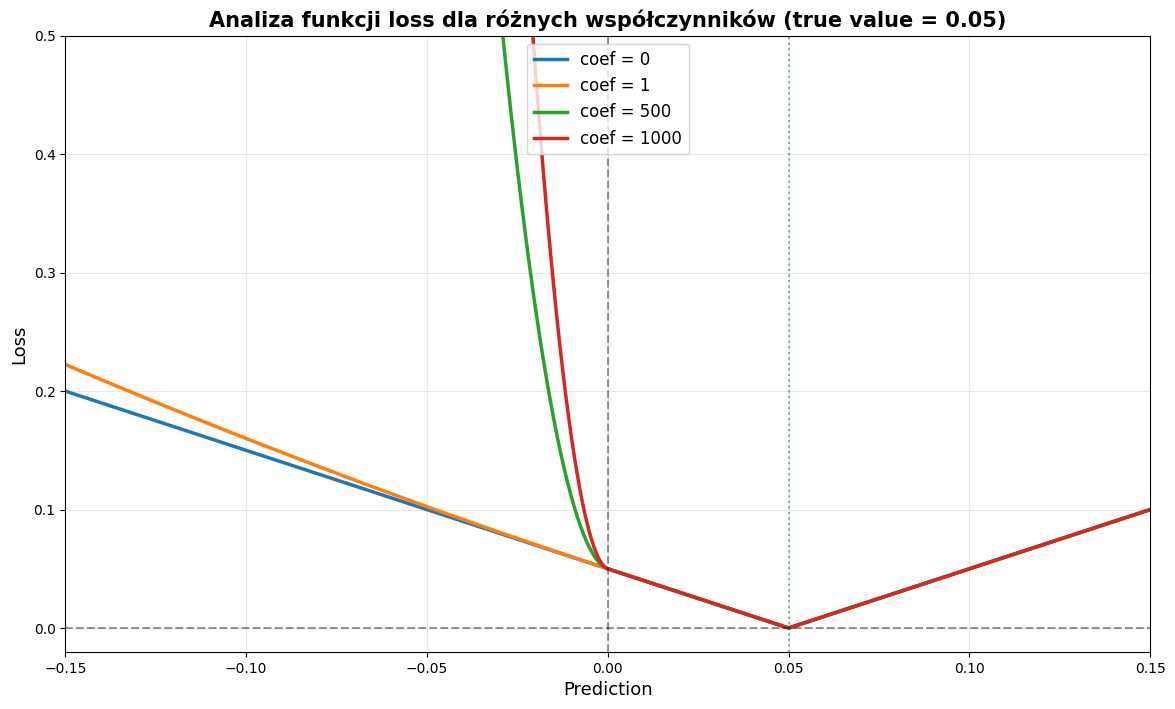

In [6]:
predictions = np.linspace(-0.2, 0.2, 500)
coef_values = [0, 1, 500, 1000]
true_value = 0.05

plt.figure(figsize=(14, 8))

for coef in coef_values:
    losses = []
    for pred in predictions:
        if true_value * pred < 0:
            loss = coef * pred**2 + abs(true_value - pred)
        else:
            loss = abs(true_value - pred)
        losses.append(loss)
    
    plt.plot(predictions, losses, label=f'coef = {coef}', linewidth=2.5)

plt.xlabel('Prediction', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.title(f'Analiza funkcji loss dla różnych współczynników (true value = {true_value})', 
          fontsize=15, fontweight='bold')
plt.legend(fontsize=12, loc='upper center')
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.4, linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.4, linewidth=1.5)
plt.axvline(x=true_value, color='green', linestyle=':', alpha=0.5, linewidth=1.5, label=f'True value = {true_value}')
plt.xlim(-0.15, 0.15)
plt.ylim(-0.02, 0.5)
plt.show()

Współczynnik coeff wpływa jedynie na wartości przeciwne znakiem (czyli konkretną pomyłkę ruchu podjętego na rynku). Uwypukla dodatkowo wagę tego błędu, im wieksza pomyłka tym większa strata.

Gdy współczynnik jest równy 0 (disabled), błąd nadal określany jest liniowo, bagatelizując fakt pomyłki ruchu podjętego na rynku.

### Analiza wektorowej funkcji straty dla współczynnika równego 0, 500 i 1000:

In [ ]:
import pymc as pm
from scipy.optimize import fmin

def stock_loss_vect(factual_vect, predicted, coef=100):
    loss_vect = np.zeros_like(factual_vect)
    ix_vect = factual_vect * predicted < 0
    loss_vect[ix_vect] = coef * predicted ** 2 + np.abs(factual_vect[ix_vect] - predicted)
    loss_vect[~ix_vect] = np.abs(factual_vect[~ix_vect] - predicted)
    return loss_vect.mean()

with pm.Model() as model:
    std = pm.Uniform("std", 0, 100)
    beta = pm.Normal("beta", mu=0, sigma=100)
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    mean = pm.Deterministic("mean", alpha + beta * X.ravel())
    obs = pm.Normal("obs", mu=mean, sigma=std, observed=y)
    
    idata = pm.sample(2000, tune=1000, return_inferencedata=True, random_seed=42)

print(pm.summary(idata, var_names=["alpha", "beta", "std"]))

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
Initializing NUTS using jitter+adapt_diag...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [std, beta, alpha]
NUTS: [std, beta, alpha]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 137 seconds.



Sampling zakończony!
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  0.000  0.001  -0.002    0.002        0.0      0.0   10812.0    6147.0   
beta   0.469  0.038   0.399    0.540        0.0      0.0   12014.0    6257.0   
std    0.010  0.001   0.009    0.012        0.0      0.0   11415.0    6010.0   

       r_hat  
alpha    1.0  
beta     1.0  
std      1.0  


In [8]:
std_samples = idata.posterior["std"].values.flatten()
alpha_samples = idata.posterior["alpha"].values.flatten()
beta_samples = idata.posterior["beta"].values.flatten()
N = std_samples.shape[0]

print(f"Liczba próbek: {N}")
print(f"Alpha - średnia: {alpha_samples.mean():.4f}, std: {alpha_samples.std():.4f}")
print(f"Beta - średnia: {beta_samples.mean():.4f}, std: {beta_samples.std():.4f}")
print(f"Std - średnia: {std_samples.mean():.4f}, std: {std_samples.std():.4f}")

Liczba próbek: 8000
Alpha - średnia: 0.0002, std: 0.0010
Beta - średnia: 0.4687, std: 0.0376
Std - średnia: 0.0101, std: 0.0007


### Optymalizacja:

In [18]:
coef_values = [0, 500, 1000]
trade_signals = np.linspace(X.min(), X.max(), 50)
opt_predictions_dict = {}

for coef in coef_values:
    opt_predictions_dict[coef] = np.zeros(50)
    
    for i, signal in enumerate(trade_signals):
        noise = std_samples * np.random.randn(N)
        possible_outcomes = alpha_samples + beta_samples * signal + noise
        
        def tomin(pred):
            return stock_loss_vect(possible_outcomes, pred, coef=coef)
        
        opt_predictions_dict[coef][i] = fmin(tomin, 0, disp=False)

### Wykresy predykcji dla róznych wartości *coef*:

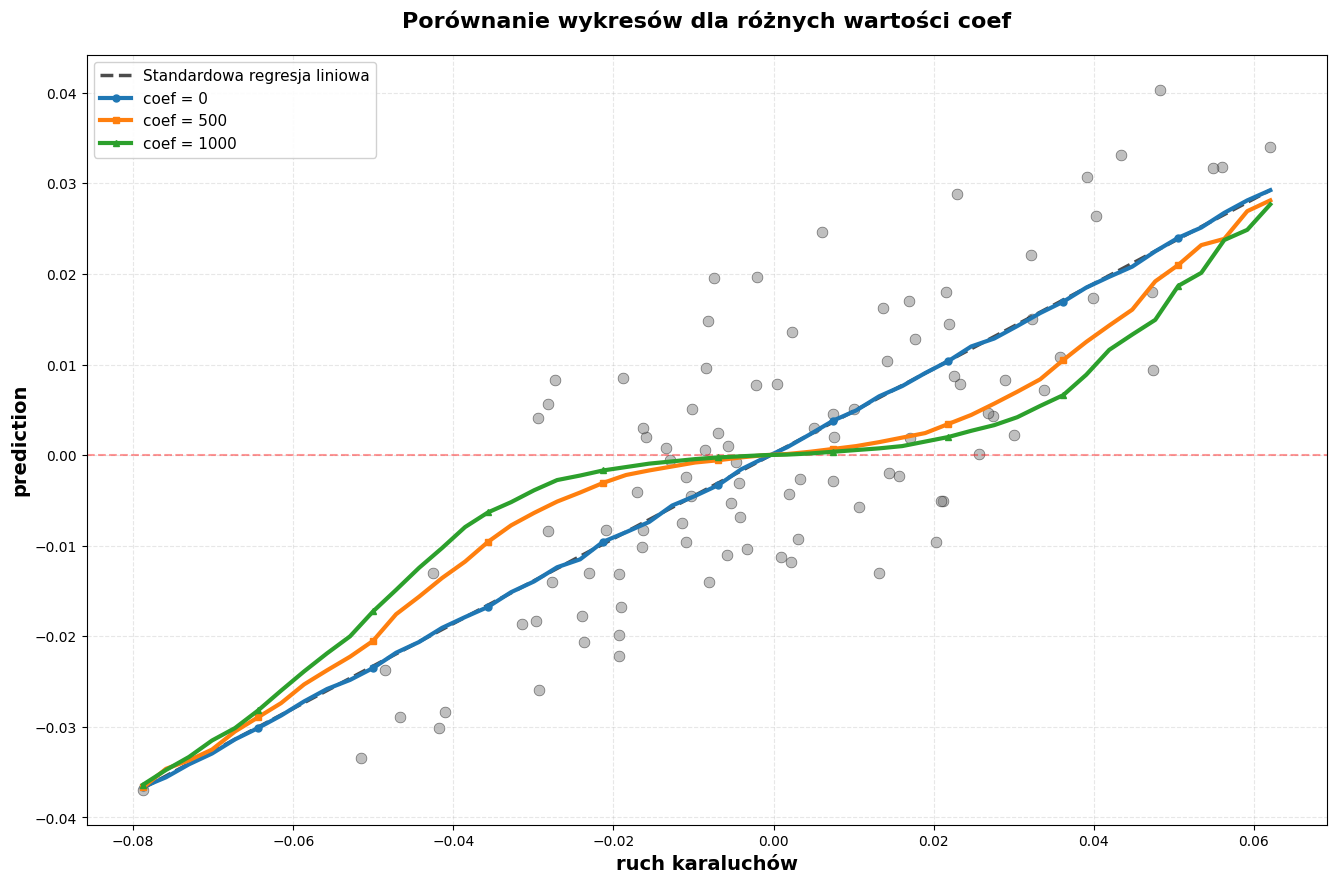

In [20]:
plt.figure(figsize=(16, 10))

plt.scatter(X.ravel(), y, c='gray', alpha=0.5, s=60, edgecolors='black', linewidth=0.5, zorder=1)
plt.plot(X.ravel()[sort_idx], y_pred_sorted, c='black', linewidth=2.5, 
         label='Standardowa regresja liniowa', linestyle='--', alpha=0.7, zorder=2)

colors_coef = ['C0', 'C1', 'C2']
markers = ['o', 's', '^']

for idx, coef in enumerate(coef_values):
    plt.plot(trade_signals, opt_predictions_dict[coef], 
             c=colors_coef[idx], linewidth=3, 
             label=f'coef = {coef}', 
             marker=markers[idx], markersize=5, markevery=5, zorder=3+idx)

plt.xlabel('ruch karaluchów', fontsize=14, fontweight='bold')
plt.ylabel('prediction', fontsize=14, fontweight='bold')
plt.title('Porównanie wykresów dla różnych wartości coef', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.4, linewidth=1.5)
plt.show()

### Wnioski:

Wykres przy zerowej wartości *coef* jest równy standardowej regresji liniowej.

Im większy współczynnik *coef*, tym bardziej wykres wypłaszcza się w okolicach 0.

Im większy współczynnik, tym bardziej określamy zachowawczość przy podejmowaniu decyzji na rynku. Podejmujemy dopiero wtedy, gdy przesłanki są znaczące - dopiero przy szybszym biegu karaluchów podejmujemy działanie.